<a href="https://colab.research.google.com/github/AR-Ashik-9997/Universal-ML-Template/blob/main/Universal_ML_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import inf

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, root_mean_squared_error, r2_score

# Classifier and Regressor imports
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression

In [5]:
from IPython.utils.sysinfo import num_cpus
class UniversalMLPipeline:
  def __init__(self,data_path,target_column,problem_type='classification'):
    self.data_path=data_path
    self.target_column=(target_column.strip())
    self.problem_type=problem_type.lower()
    self.data=None
    self.X_train=None
    self.X_test=None
    self.y_train=None
    self.y_test = None
    self.preprocessor = None
    self.best_model = None

# data loading function
  def load_data(self):
    print("Data Loading.....")
    self.data=pd.read_csv(self.data_path)
    self.data.columns = self.data.columns.str.strip()
    print(f"Data shape:{self.data.shape}\n")
    display(self.data.head())
    print("\n\n")
    display(self.data.info())
    print('\n\n Data Describe')
    display(self.data.describe().T)
    print("\n\n Data null value check")
    display(self.data.isna().sum())
    return self.data.head()


# Eda section
  def build_eda_graph(self):
    if self.data is None:
      return

    print('\n \n Explory Data Analysis \n')
    plt.figure(figsize=(8,4))
    if self.problem_type=='classification':
      sns.countplot(data=self.data,x=self.target_column)
      plt.title(f"Target distribution: {self.target_column}")
    else:
      sns.histplot(self.data[self.target_column],kde=True,color='blue')
      plt.title(f"Target distribution: {self.target_column}")

    plt.show()

    print('\n\n\n')

    # Numerical Features - Histogram
    num_cols=self.data.select_dtypes(include=['number']).columns
    if len(num_cols)>0:
      self.data[num_cols].hist(figsize=(12,15),bins=10)
      plt.title("Feature distribution")
      plt.tight_layout()
      plt.show()

    print('\n\n\n')

    # correlation Heatmap
    plt.figure(figsize=(10,6))
    if len(num_cols)>1:
      cor_mat=self.data[num_cols].corr()
      sns.heatmap(cor_mat,cmap='coolwarm',annot=True)
      plt.title("Correlation Heatmap (only numeric feature)")
      plt.show()

    print('\n\n\n')

    # outlier Detection
    if len(num_cols)>0:
      plt.figure(figsize=(10,6))
      sns.boxplot(data=self.data[num_cols],palette='viridis')
      plt.xticks(rotation=45)
      plt.title("Boxplot for outlier Detection")
      plt.tight_layout()
      plt.show()



 # preprocessing pipeline
  def build_preprocessing_pipeline(self,X,threshold=10):
    num_cols=[]
    cat_cols=[]

    for col in X.columns:
      if X[col].dtype.kind in "iifu":
        if X[col].nunique()<=threshold:
          cat_cols.append(col)
        else:
          num_cols.append(col)
      else:
        cat_cols.append(col)

    num_pipeline=Pipeline(
        steps=[
            ("imputer",SimpleImputer(strategy='median')),
            ("scaler",StandardScaler()),
        ])

    cat_pipeline=Pipeline(
        steps=[
            ("imputer",SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])

  # ColumnTransform
    self.preprocessor=ColumnTransformer(
        transformers=[
            ("num",num_pipeline,num_cols),
            ('cat',cat_pipeline,cat_cols)
        ],
        remainder="passthrough"

        )

# data Splitting
  def split_data(self,test_size=0.2,randome_state=42):

    x=self.data.drop(columns=[self.target_column],axis=1)
    y=self.data[self.target_column]

    self.build_preprocessing_pipeline(x)

    stratify=y if self.problem_type=='classification' else None

    self.X_train,self.X_test,self.y_train,self.y_test=train_test_split(x,y,test_size=test_size,random_state=randome_state,stratify=stratify)

    self.X_train=self.preprocessor.fit_transform(self.X_train)
    self.X_test=self.preprocessor.transform(self.X_test)
    print('\n')
    print("Completed Preprocessing")


# data Splitting
  def model_train_evaluting(self):

    if self.problem_type == "classification":
        models = {
            "LogisticRegression": LogisticRegression(max_iter=1000),
            "RandomForestClassifier": RandomForestClassifier(random_state=42),
        }
        best_score = 0.0

    elif self.problem_type == "regression":
        models = {
            "LinearRegression": LinearRegression(),
            "RandomForestRegressor": RandomForestRegressor(random_state=42),
        }
        best_score = float("inf")
    else:
        raise ValueError(
            "Only Classification and regression algorithm is allowed "
        )

    self.best_model = None

    for name, model in models.items():
        model.fit(self.X_train, self.y_train)
        prediction = model.predict(self.X_test)

        if self.problem_type == "classification":
            acc = accuracy_score(self.y_test, prediction)
            print(f"{name} Accuracy: {acc:.4f}")

            if acc > best_score:
                best_score = acc
                self.best_model = model

        else:
            rmse = root_mean_squared_error(self.y_test, prediction)
            print(f"{name} RMSE: {rmse:.4f}")

            if rmse < best_score:
                best_score = rmse
                self.best_model = model

    print(f"Best model is {self.best_model.__class__.__name__}")


Data Loading.....
Data shape:(1338, 7)



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None



 Data Describe


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801




 Data null value check


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0



 
 Explory Data Analysis 



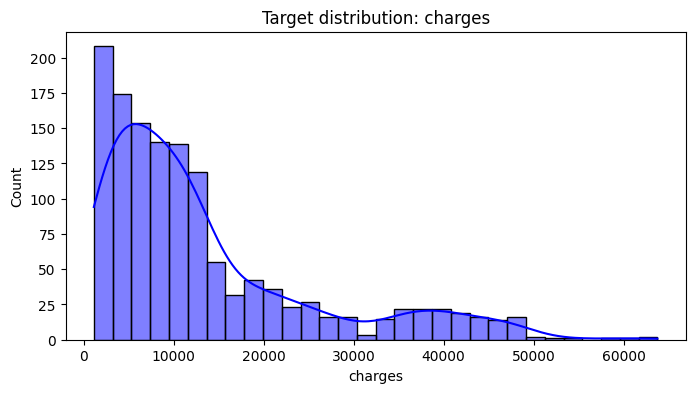

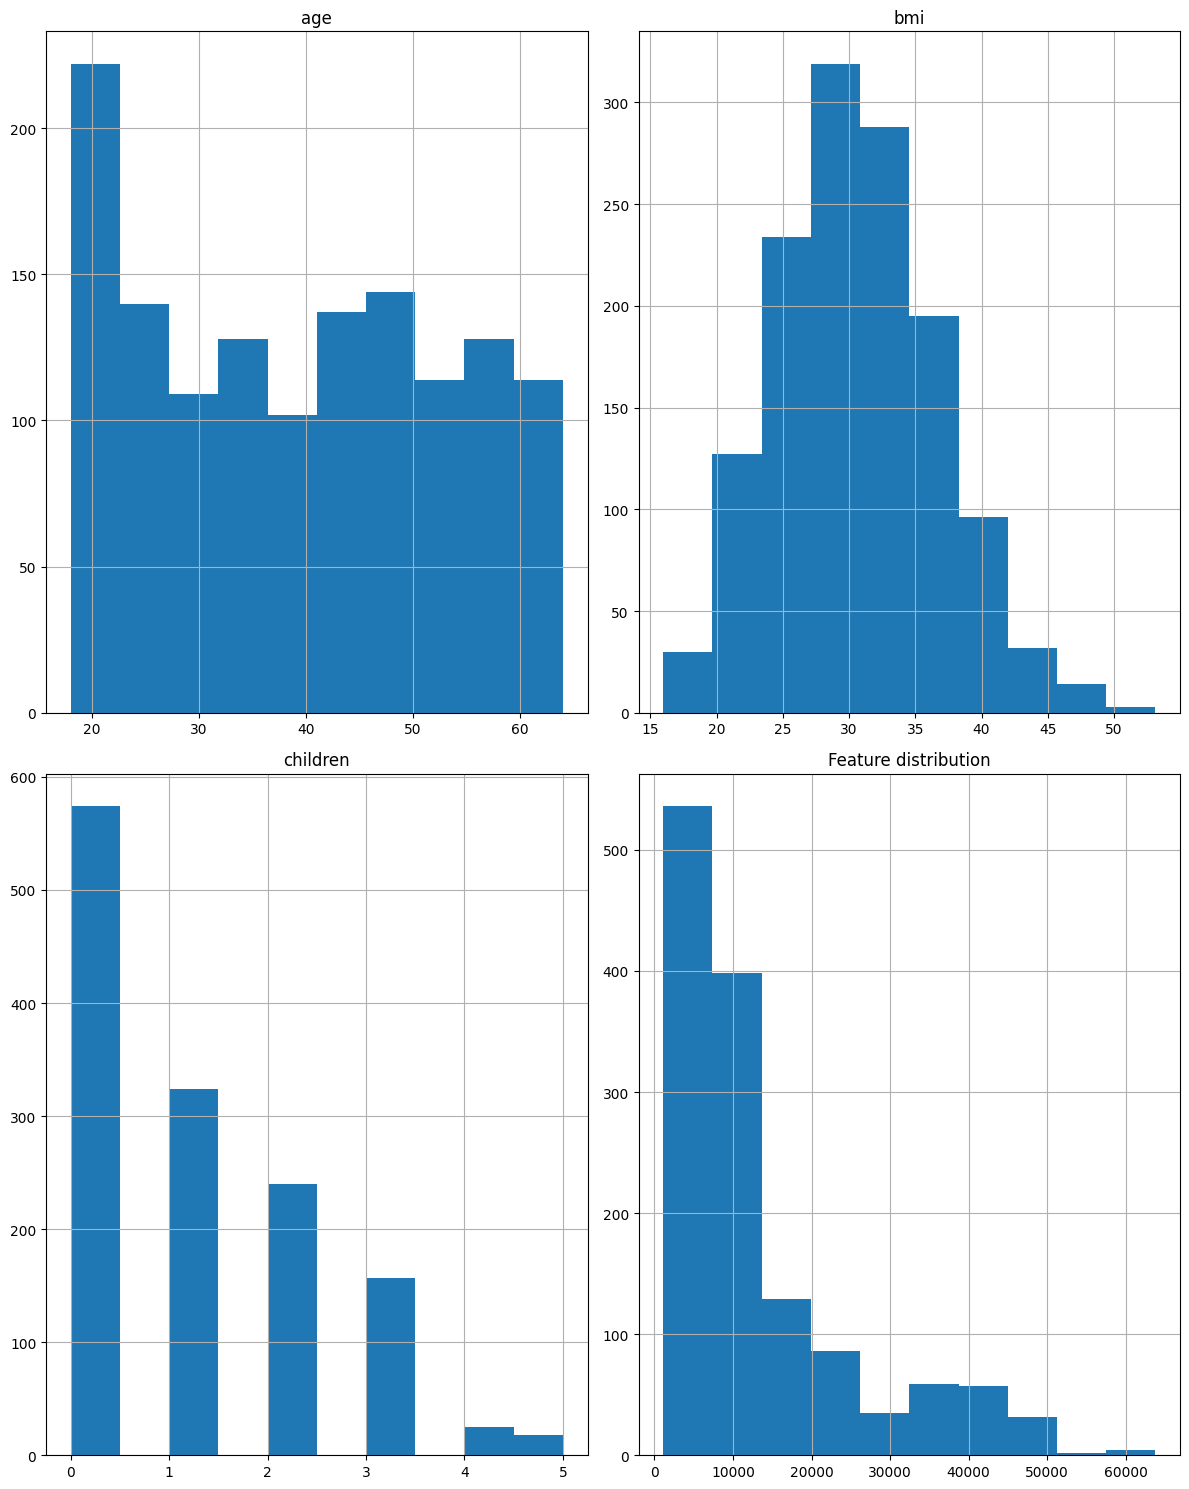

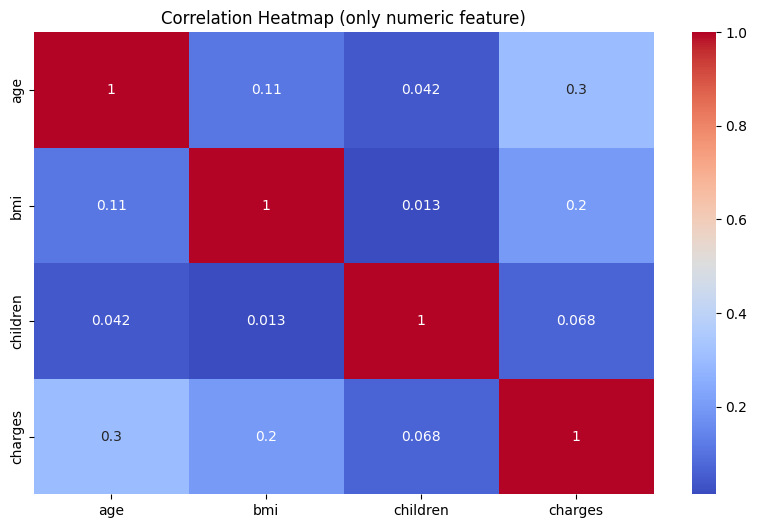

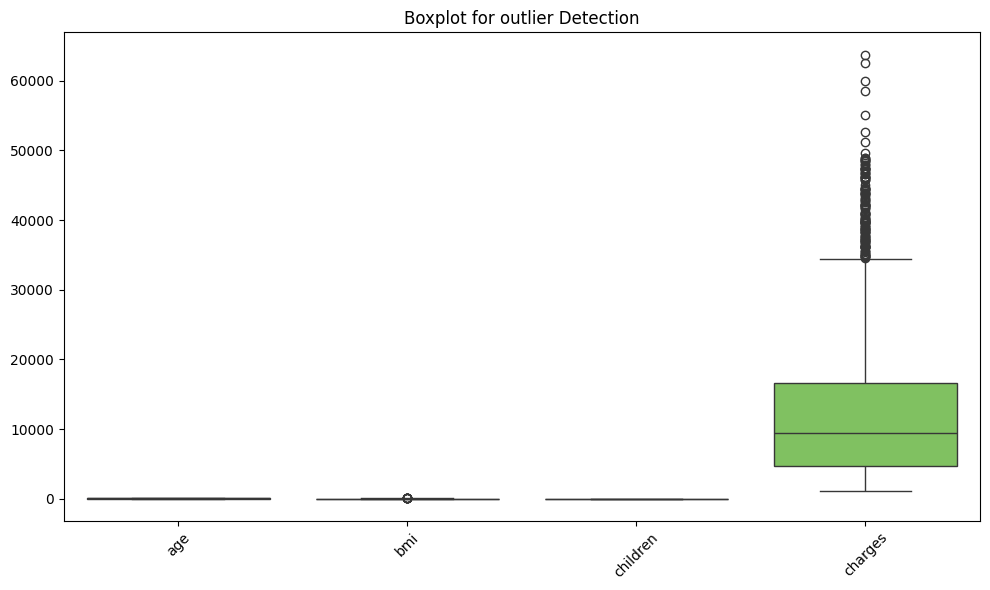



Completed Preprocessing
LinearRegression RMSE: 5810.0284
RandomForestRegressor RMSE: 4629.8498
Best model is RandomForestRegressor


In [6]:
if __name__=="__main__":
  DATA_PATH="/content/insurance.csv"
  TARGET_COLUMN="charges"
  PROBLEM="regression"
pipeline=UniversalMLPipeline(data_path=DATA_PATH,target_column=TARGET_COLUMN,problem_type=PROBLEM)
try:
  pipeline.load_data()
  pipeline.build_eda_graph()
  pipeline.split_data()
  pipeline.model_train_evaluting()
except FileNotFoundError:
  print("File note found")